# Flat-Dalitz toy-MC integration with 1M events

This example replaces the deterministic normalization grid by one million Monte Carlo points uniform in the physical conventional Dalitz plane $(s_{12},s_{13})$. The amplitude model is a simple non-CPV $B^+\to K^+\pi^+\pi^-$ model with $K^*(892)^0$, $\rho(770)^0$ and a non-resonant component.

The generated integration events are unweighted in the sampling sense: their density is constant over the physical Dalitz area. Because DalitzPlotFitter defines numerical integrals as `mean(sample.weights * f)`, each event stores the same constant integration weight, equal to the physical Dalitz area. Therefore the Monte Carlo estimate reproduces the absolute integral $\int f\,ds_{12}\,ds_{13}$ rather than only its average over the Dalitz plot.


In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from dalitzplotfitter import (
    DecayChannel,
    DecayModel,
    FitSession,
    NonResonant,
    Parameter,
    PhaseSpaceSample,
    RealImag,
    Resonance,
    dalitz_s13_limits,
    enable_x64,
    generate_toy,
    plot_dalitz,
)

enable_x64()


## Uniform sampling of the physical Dalitz area

At fixed $s_{12}$ the physical interval is $s_{13}^{\min}(s_{12}) < s_{13} < s_{13}^{\max}(s_{12})$. A sample uniform in two-dimensional Dalitz area therefore has marginal density

$$p(s_{12}) \propto s_{13}^{\max}(s_{12})-s_{13}^{\min}(s_{12}).$$

We tabulate and invert that one-dimensional CDF, then draw $s_{13}$ uniformly inside its allowed interval. This produces no rejection and no dynamical weighting.


In [2]:
def generate_flat_dalitz(
    channel,
    size=1_000_000,
    *,
    seed=2301,
    cdf_resolution=200_001,
):
    M = float(channel.parent_mass)
    m1, m2, m3 = map(float, channel.daughter_masses)

    s12_min = (m1 + m2) ** 2
    s12_max = (M - m3) ** 2

    # The marginal density for a uniform 2D Dalitz sample is the
    # physical s13 width at each s12.
    s12_axis = np.linspace(s12_min, s12_max, int(cdf_resolution))
    low_axis, high_axis = dalitz_s13_limits(
        jnp.asarray(s12_axis),
        mother_mass=M,
        masses=(m1, m2, m3),
    )
    width = np.asarray(high_axis - low_axis, dtype=float)

    ds = np.diff(s12_axis)
    cumulative_area = np.concatenate(
        ([0.0], np.cumsum(0.5 * (width[1:] + width[:-1]) * ds))
    )
    dalitz_area = float(cumulative_area[-1])
    cdf = cumulative_area / dalitz_area

    rng = np.random.default_rng(seed)
    s12 = np.interp(rng.random(size), cdf, s12_axis)

    low, high = dalitz_s13_limits(
        jnp.asarray(s12),
        mother_mass=M,
        masses=(m1, m2, m3),
    )
    low = np.asarray(low)
    high = np.asarray(high)
    s13 = low + rng.random(size) * (high - low)

    invariant_sum = M**2 + m1**2 + m2**2 + m3**2
    s23 = invariant_sum - s12 - s13

    # Events are flat/unweighted. The constant stored weight is only the
    # integration-volume factor required by integral = mean(weight * f).
    integration_weights = np.full(size, dalitz_area, dtype=float)

    return PhaseSpaceSample(
        s12=jnp.asarray(s12),
        s13=jnp.asarray(s13),
        s23=jnp.asarray(s23),
        weights=jnp.asarray(integration_weights),
    )


integration events : 1,000,000
Dalitz area        : 348.45381866 GeV^4
constant weights   : True


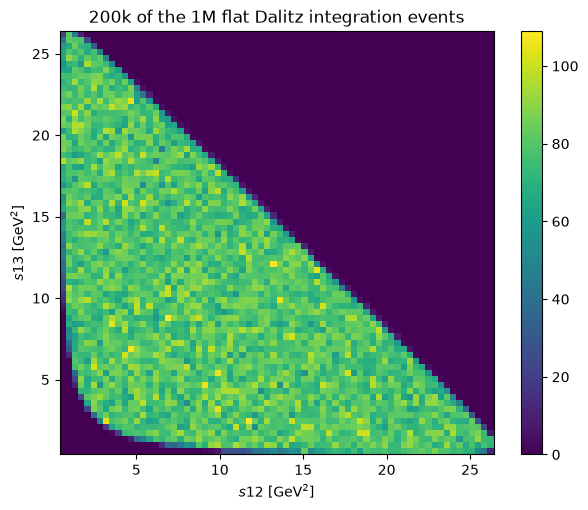

In [3]:
channel = DecayChannel("B+", ("K+", "pi+", "pi-"))

flat_mc = generate_flat_dalitz(channel, 1_000_000, seed=2301)

print(f"integration events : {flat_mc.size:,}")
print(f"Dalitz area        : {float(flat_mc.weights[0]):.8f} GeV^4")
print(f"constant weights   : {bool(jnp.all(flat_mc.weights == flat_mc.weights[0]))}")

# A subset is enough for visualization.
plot_dalitz(
    flat_mc.take(jnp.arange(200_000)),
    x="s12",
    y="s13",
    title="200k of the 1M flat Dalitz integration events",
)
plt.show()


The two-dimensional density above should be uniform inside the physical boundary. Its one-dimensional projections are **not** expected to be flat, because the available width in the other invariant changes across the Dalitz plot.


## Same amplitude model, two integration backends

`grid_model` uses the usual deterministic Square-Dalitz quadrature and serves as a reference. `mc_model` is identical except that every normalization integral uses the 1M-event flat sample.


In [4]:
truth = {"rho.x": 0.55, "rho.y": 0.10}

def build_model(*, normalization_sample=None):
    rho_x = Parameter.coefficient(
        "rho.x", truth["rho.x"], bounds=(-2.0, 2.0), owner="rho", step=0.02
    )
    rho_y = Parameter.coefficient(
        "rho.y", truth["rho.y"], bounds=(-2.0, 2.0), owner="rho", step=0.02
    )

    normalization_kwargs = (
        {
            "normalization_method": "square-dalitz",
            "normalization_resolution": 350,
            "normalization_pair": (0, 2),
        }
        if normalization_sample is None
        else {"normalization_sample": normalization_sample}
    )

    return DecayModel(
        channel,
        [
            Resonance(
                "Kstar",
                (0, 2),
                RealImag(1.0, 0.0),
                mass=0.8958,
                width=0.0474,
                spin=1,
            ),
            Resonance(
                "rho",
                (1, 2),
                RealImag(rho_x, rho_y),
                mass=0.7753,
                width=0.1491,
                spin=1,
            ),
            NonResonant(RealImag(-0.25, 0.10)),
        ],
        **normalization_kwargs,
    )

grid_model = build_model()
mc_model = build_model(normalization_sample=flat_mc)

print("grid:", grid_model.normalization_scheme)
print("MC  :", mc_model.normalization_scheme)


grid: {'method': 'square-dalitz', 'adaptive': False, 'pair': (0, 2), 'resolution': 350}
MC  : {'method': 'toy-mc', 'adaptive': False, 'sample_size': 1000000, 'weighted': True, 'chunk_size': 100000}


## Compare the normalization matrices

The object that must agree for an amplitude fit is the complete complex normalization matrix $M_{ij}=\int F_i^*F_j\,ds_{12}\,ds_{13}$, not only one total normalization evaluated at a particular coefficient vector.


In [5]:
probe = grid_model.generate_phase_space(64, seed=2302)

grid_cache = grid_model.prepare_cache(probe)
mc_cache = mc_model.prepare_cache(probe)

M_grid = np.asarray(grid_cache.normalization_matrix(truth))
M_mc = np.asarray(mc_cache.normalization_matrix(truth))

relative_frobenius = np.linalg.norm(M_mc - M_grid) / np.linalg.norm(M_grid)
max_abs_difference = np.max(np.abs(M_mc - M_grid))

print(f"relative Frobenius difference : {relative_frobenius:.4e}")
print(f"max |Delta M_ij|              : {max_abs_difference:.4e}")

print("\nGrid matrix:")
print(M_grid)
print("\n1M flat-MC matrix:")
print(M_mc)


relative Frobenius difference : 6.1470e-04
max |Delta M_ij|              : 5.7127e-04

Grid matrix:
[[ 1.00000000e+00-1.01256693e-18j  7.45770207e-02-1.41064877e-02j
  -1.75911258e-17-8.50305407e-18j]
 [ 7.45770207e-02+1.41064877e-02j  1.00000000e+00-1.31541373e-19j
  -2.09957878e-16+4.43825785e-16j]
 [-1.75952630e-17+7.97362924e-18j -2.05056653e-16-4.41706336e-16j
   1.00000000e+00+0.00000000e+00j]]

1M flat-MC matrix:
[[ 1.00000000e+00+1.59587921e-19j  7.45061374e-02-1.43019557e-02j
  -2.79368866e-04-3.48331793e-04j]
 [ 7.45061374e-02+1.43019557e-02j  1.00000000e+00+2.12247093e-19j
  -1.62593431e-04-5.47647189e-04j]
 [-2.79368866e-04+3.48331793e-04j -1.62593431e-04+5.47647189e-04j
   1.00000000e+00+0.00000000e+00j]]


In [6]:
ff_grid = np.asarray(grid_model.fit_fractions(truth))
ff_mc = np.asarray(mc_model.fit_fractions(truth))
names = [component.name for component in grid_model.amplitude_model.components]

print(f"{'component':16s} {'grid':>12s} {'1M flat MC':>12s} {'difference':>12s}")
for name, fg, fm in zip(names, ff_grid, ff_mc):
    print(f"{name:16s} {fg:12.6f} {fm:12.6f} {fm-fg:+12.3e}")


component                grid   1M flat MC   difference
Kstar                0.680339     0.680200   -1.386e-04
rho                  0.212606     0.212563   -4.332e-05
NR                   0.049325     0.049315   -1.005e-05


## Closure fit using the flat-MC normalization

The pseudo-data below are generated with the deterministic reference model, while the likelihood fit uses `mc_model`. Thus the fit normalization, component normalization, fit fractions and interference terms are all obtained from the independent 1M-event flat integration sample.


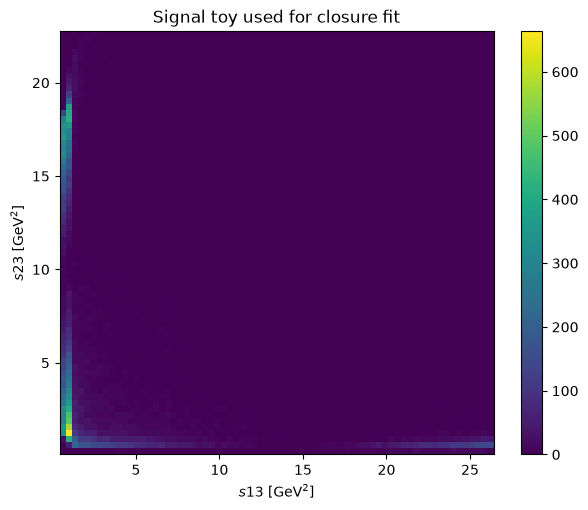

In [7]:
data = generate_toy(
    grid_model,
    30_000,
    parameters=truth,
    seed=2303,
)

plot_dalitz(data, x="s13", y="s23", title="Signal toy used for closure fit")
plt.show()


valid=True  NLL=90314.466972
parameter                           value            error
rho.x                            0.549544        0.0055784
rho.y                           0.0769506        0.0160426
Fit fractions (physical)
component                    fraction [%]
Kstar                              68.267
rho                                21.021
NR                                  4.949
sum                                94.237

Fit fractions from the same 1M-event integration toy:
Fit fractions (physical)
component                    fraction [%]
Kstar                              68.267
rho                                21.021
NR                                  4.949
sum                                94.237

Interference fractions
pair                                                  fraction [%]
Kstar x rho                                                  5.741
Kstar x NR                                                   0.014
rho x NR                                    

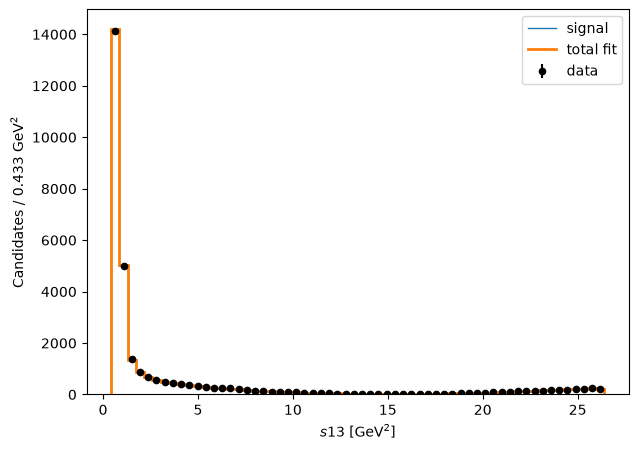

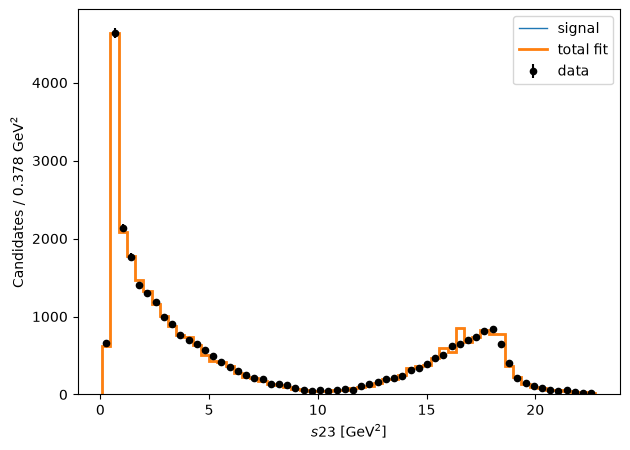

In [9]:
session = FitSession(mc_model, data)
result = session.fit(
    {"rho.x": 0.30, "rho.y": -0.05},
    simplex=True,
    ncall=30_000,
)

session.report(result)
print("\nFit fractions from the same 1M-event integration toy:")
session.print_fit_fractions(result, include_interference=True)

session.plot_projection(result, "s13", projection_size=500_000)
plt.show()
session.plot_projection(result, "s23", projection_size=500_000)
plt.show()


## ROOT input variant

The same workflow also works when the flat integration sample comes from a ROOT tree. If the tree contains truly flat Dalitz events but no weight branch, `read_phase_space_sample` assigns unit weights. For absolute Dalitz-area integrals, multiply those unit weights by the known physical Dalitz area before passing the sample to `DecayModel`. If only normalized single-channel PDFs or fit fractions are needed, a common overall factor cancels, but carrying the area factor keeps the numerical integral convention exact.
